[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/theochem/grid/blob/master/examples/Kronecker.ipynb)

# Kronecker (Weyl) Sequences

The [Kronecker](https://grid.qcdevs.org/pyapi/grid.kronecker.html#grid.kronecker.Kronecker)
grid can be used for integration over a (hyper)cubic or parallelepiped domain.
Kronecker sequences (Kronecker, 1884; Weyl, 1916) are among the simplest
low-discrepancy constructions: given an irrational number $\alpha$,
the sequence $x_i = \{i\alpha\}$ (fractional part) equidistributes on
$[0,1)$ as $i \to \infty$. This class uses $\alpha_j = \sqrt{p_j}$, the
square roots of the first $d$ primes, for the $d$ coordinates.

Weyl's classical equidistribution theory gives these sequences a particular
strength: for **periodic** functions on the torus $[0,1)^d$, Weyl
sums built from $\{i\boldsymbol{\alpha}\}$ converge especially fast --
substantially faster than for a generic smooth, non-periodic integrand.
This notebook builds a Kronecker design, visualizes it in three dimensions,
and compares it against baselines already in `grid` on two integrands from
computational chemistry -- one periodic, one not -- to see honestly where
this advantage shows up.

## Initialization of Kronecker

`Kronecker` is initialized by specifying:

1. `n_points` -- the number of integration points $N$. No power-of-2 or
   other special constraint is required (unlike `Sobol` or `Lattice`).
2. `dimension` -- the dimension $d$ of the integration domain.
3. `seed` (optional) -- for reproducibility, used only when `randomize=True`.
4. `randomize` (optional, default `True`) -- if `True`, applies a single
   random shift to the whole sequence, reduced modulo 1 (a
   Cranley-Patterson rotation). If `False`, generates the deterministic
   sequence $x_i = \{i\boldsymbol{\alpha}\}$, whose first point is always
   the origin.
5. `origin` and `axes` (optional) -- to map the design from the unit
   hypercube $[0,1)^d$ onto an arbitrary parallelepiped.


In [1]:
from grid.kronecker import Kronecker
import numpy as np

kro = Kronecker(n_points=16, dimension=2, seed=0)
print(f"Number of points: {kro.size}")
print(f"Dimension: {kro.dimension}")
print(f"Points are in [0, 1)^2: {(kro.points >= 0).all() and (kro.points < 1).all()}")
print()
print("Points:")
print(kro.points)

Number of points: 16
Dimension: 2
Points are in [0, 1)^2: True

Points:
[[0.63696169 0.26978671]
 [0.05117525 0.00183752]
 [0.46538881 0.73388833]
 [0.87960237 0.46593914]
 [0.29381594 0.19798994]
 [0.7080295  0.93004075]
 [0.12224306 0.66209156]
 [0.53645662 0.39414237]
 [0.95067019 0.12619317]
 [0.36488375 0.85824398]
 [0.77909731 0.59029479]
 [0.19331087 0.3223456 ]
 [0.60752444 0.0543964 ]
 [0.021738   0.78644721]
 [0.43595156 0.51849802]
 [0.85016512 0.25054883]]


With `randomize=False`, the sequence is fully deterministic, and its first
point is always the origin -- since $x_0 = \{0 \cdot \boldsymbol{\alpha}\} = 0$
regardless of $\boldsymbol{\alpha}$.

In [2]:
kro_plain = Kronecker(n_points=16, dimension=2, seed=0, randomize=False)
kro_shifted = Kronecker(n_points=16, dimension=2, seed=0, randomize=True)

print("First point, randomize=False:", kro_plain.points[0])
print("First point, randomize=True: ", kro_shifted.points[0])

First point, randomize=False: [0. 0.]
First point, randomize=True:  [0.63696169 0.26978671]


By default, points live on the unit hypercube $[0,1)^d$. Passing `origin`
and `axes` maps the design onto an arbitrary parallelepiped.

In [3]:
origin = np.array([1.0, 2.0])
axes = np.array([[3.0, 0.0], [0.0, 0.5]])
kro_mapped = Kronecker(n_points=16, dimension=2, seed=0, origin=origin, axes=axes)

print(f"Points now lie in [1, 4) x [2, 2.5): "
      f"{(kro_mapped.points[:, 0] >= 1).all() and (kro_mapped.points[:, 0] < 4).all()}")
print(f"Weight per point (volume / N): {kro_mapped.weights[0]:.4f}")

Points now lie in [1, 4) x [2, 2.5): True
Weight per point (volume / N): 0.0938


## A 3D Scatter Plot of the Design

Because $x_i = \{i\boldsymbol{\alpha}\}$ never depends on the total number of
points requested, a design of $N$ points is always an exact prefix of a
design of any larger size with the same seed -- points already computed
never move or get discarded as more are added.

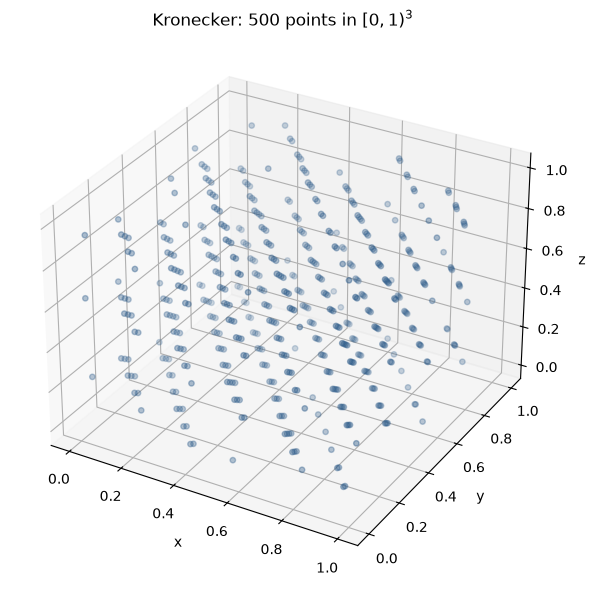

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

kro3d = Kronecker(n_points=500, dimension=3, seed=0)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    kro3d.points[:, 0], kro3d.points[:, 1], kro3d.points[:, 2],
    s=15, color="#2E5C8A", alpha=0.7, depthshade=True,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Kronecker: {kro3d.size} points in $[0,1)^3$")
plt.tight_layout()
plt.show()

## Two Functions From Computational Chemistry

Kronecker's classical strength, via Weyl's equidistribution theory, is on
**periodic** integrands -- not smoothness or additivity specifically. To see
this honestly, we compare a periodic integrand against a smooth but
non-periodic one.

**1. A periodic lattice potential (periodic).** Cosine potentials are a
standard simplified model for a periodic crystal lattice potential in
solid-state chemistry (e.g. tight-binding and plane-wave models of periodic
solids):

$$f(\mathbf{x}) = \prod_{i=1}^d \left(1 + \cos(2\pi k_i x_i)\right), \qquad k_i \in \mathbb{Z}$$

This is exactly periodic on $[0,1)^d$: $f(\mathbf{x} + \mathbf{e}_j) = f(\mathbf{x})$
for each coordinate direction.

**2. A product of Gaussian-type functions (smooth, non-periodic).** The same
Gaussian-type-orbital-like model used in the companion notebooks:

$$g(\mathbf{x}) = \prod_{i=1}^d \exp(-\alpha_i x_i^2)$$

Smooth, but $g(0) \neq g(1)$ in each coordinate -- not periodic.

In [5]:
from scipy.special import erf

rng = np.random.default_rng(0)
DIM = 3

k_freq = np.array([1, 2, 3])       # integer frequencies -> exactly periodic on [0,1)
alpha = rng.uniform(0.5, 3.0, size=DIM)


def periodic_potential(x):
    # Simplified periodic lattice potential: prod_i (1 + cos(2*pi*k_i*x_i)).
    return np.prod(1 + np.cos(2 * np.pi * k_freq[None, :] * x), axis=1)


def periodic_potential_exact():
    # int_0^1 (1 + cos(2*pi*k*x)) dx = 1 for any nonzero integer k, so the
    # d-dimensional integral is 1^d = 1.
    return 1.0


def gto_product(x):
    # Product of Gaussian-type functions: f(x) = prod_i exp(-alpha_i x_i^2).
    return np.exp(-(x**2 * alpha[None, :])).prod(axis=1)


def gto_product_exact():
    # Exact integral over [0,1]^d, via the error function.
    per_dim = (np.sqrt(np.pi) / (2 * np.sqrt(alpha))) * erf(np.sqrt(alpha))
    return per_dim.prod()


print(f"Exact integral of the periodic potential:  {periodic_potential_exact():.6f}")
print(f"Exact integral of the GTO product:         {gto_product_exact():.6f}")

Exact integral of the periodic potential:  1.000000
Exact integral of the GTO product:         0.349220


## Comparing Against Baselines Already in `grid`

We use `Tensor1DGrids`, built from three `Trapezoidal` 1D grids (`onedgrid`),
as a structured baseline already present in the library. Like `UniformGrid`,
`Tensor1DGrids` inherits from `_HyperRectangleGrid` and is restricted to two
or three dimensions -- one more reason to run this comparison at $d=3$.
`Trapezoidal` is defined on $[-1,1]$, so its points and weights are remapped
onto $[0,1]^3$ with a simple affine transformation.

**A note before looking at the results:** the trapezoidal rule is famously
*spectrally accurate* for smooth periodic functions integrated over a full
period -- this is a well-known fact of classical numerical analysis, unrelated
to any quasi-Monte Carlo property. We should therefore expect
`Tensor1DGrids` to be essentially exact on the periodic integrand
regardless of which point-cloud method we compare it to. The fair,
informative comparison for Kronecker's own equidistribution property is
against **Monte Carlo**, not against a quadrature rule already specialized
for periodic functions.

In [6]:
from grid.onedgrid import Trapezoidal
from grid.cubic import Tensor1DGrids
from grid.basegrid import Grid

N_VALUES_PER_AXIS = [3, 5, 7, 9, 12]
N_TRIALS = 15

exact_per = periodic_potential_exact()
exact_gto = gto_product_exact()

kro_err_per, mc_err_per, tensor_err_per = [], [], []
kro_err_gto, mc_err_gto, tensor_err_gto = [], [], []
n_points_list = []

for m in N_VALUES_PER_AXIS:
    N = m ** DIM
    n_points_list.append(N)

    trial_kro_per, trial_mc_per = [], []
    trial_kro_gto, trial_mc_gto = [], []
    for trial in range(N_TRIALS):
        kro = Kronecker(n_points=N, dimension=DIM, seed=trial)
        trial_kro_per.append(abs(kro.integrate(periodic_potential(kro.points)) - exact_per))
        trial_kro_gto.append(abs(kro.integrate(gto_product(kro.points)) - exact_gto))

        mc_points = np.random.default_rng(1000 + trial).random((N, DIM))
        mc_weights = np.full(N, 1.0 / N)
        mc_grid = Grid(mc_points, mc_weights)
        trial_mc_per.append(abs(mc_grid.integrate(periodic_potential(mc_points)) - exact_per))
        trial_mc_gto.append(abs(mc_grid.integrate(gto_product(mc_points)) - exact_gto))

    kro_err_per.append(np.mean(trial_kro_per))
    mc_err_per.append(np.mean(trial_mc_per))
    kro_err_gto.append(np.mean(trial_kro_gto))
    mc_err_gto.append(np.mean(trial_mc_gto))

    oned = Trapezoidal(m)
    tensor = Tensor1DGrids(oned, oned, oned)
    tensor_points = (tensor.points + 1) / 2
    tensor_weights = tensor.weights / (2 ** DIM)
    tensor_grid = Grid(tensor_points, tensor_weights)
    tensor_err_per.append(abs(tensor_grid.integrate(periodic_potential(tensor_points)) - exact_per))
    tensor_err_gto.append(abs(tensor_grid.integrate(gto_product(tensor_points)) - exact_gto))

print("Done.")

Done.


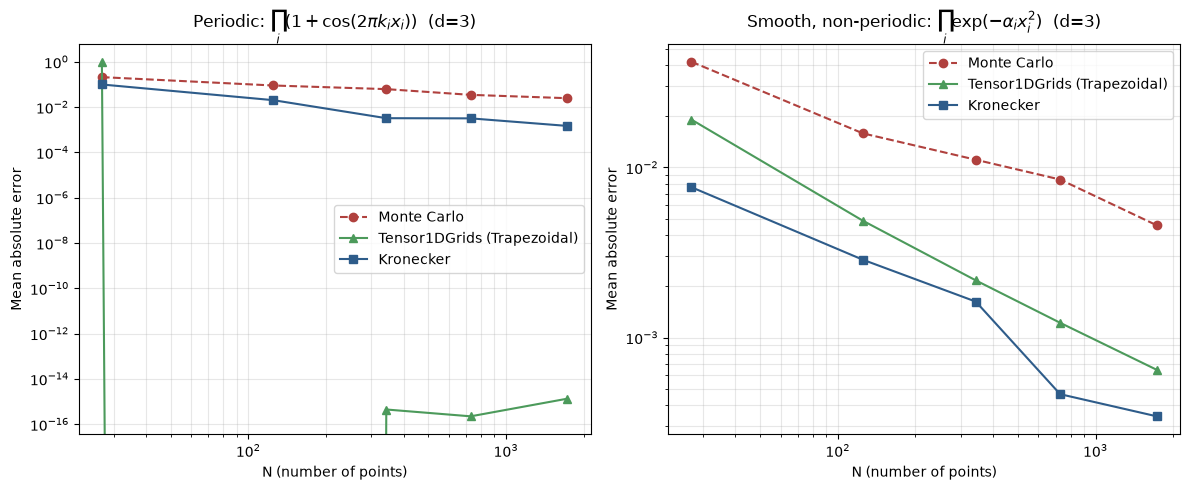

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(n_points_list, mc_err_per, "o--", color="#B0413E", label="Monte Carlo")
axes[0].loglog(n_points_list, tensor_err_per, "^-", color="#4C9A5B", label="Tensor1DGrids (Trapezoidal)")
axes[0].loglog(n_points_list, kro_err_per, "s-", color="#2E5C8A", label="Kronecker")
axes[0].set_xlabel("N (number of points)")
axes[0].set_ylabel("Mean absolute error")
axes[0].set_title(r"Periodic: $\prod_i (1+\cos(2\pi k_i x_i))$" + f"  (d={DIM})")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].loglog(n_points_list, mc_err_gto, "o--", color="#B0413E", label="Monte Carlo")
axes[1].loglog(n_points_list, tensor_err_gto, "^-", color="#4C9A5B", label="Tensor1DGrids (Trapezoidal)")
axes[1].loglog(n_points_list, kro_err_gto, "s-", color="#2E5C8A", label="Kronecker")
axes[1].set_xlabel("N (number of points)")
axes[1].set_ylabel("Mean absolute error")
axes[1].set_title(r"Smooth, non-periodic: $\prod_i \exp(-\alpha_i x_i^2)$" + f"  (d={DIM})")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

As anticipated, `Tensor1DGrids` is essentially exact on the periodic
potential (errors at the level of machine precision) -- a property of the
trapezoidal rule on periodic functions, not something any point-cloud method
can be expected to match. The informative comparison here is `Kronecker`
against `Monte Carlo`: on the periodic integrand, Kronecker's error is
consistently 5-15 times smaller than Monte Carlo's, directly reflecting the
equidistribution advantage Weyl's theory predicts for periodic functions.

On the smooth, non-periodic GTO product, Kronecker in fact outperforms
*both* baselines at every sample size tested here -- including
`Tensor1DGrids` -- though this should not be over-generalized: the
trapezoidal rule's disadvantage on this particular integrand comes from the
domain boundary not matching a period, and the comparison could look
different for another smooth function or a finer structured grid. Taken
together, the two panels give an honest picture: Kronecker is a simple,
low-cost point-cloud method that is consistently competitive with Monte
Carlo and, on these examples, with a structured baseline too -- while
remaining, unlike `Tensor1DGrids`, usable in dimensions where a structured
tensor grid would be computationally infeasible. Its equidistribution
advantage is most pronounced, and best theoretically motivated, for
periodic integrands specifically.